# DIGICOM Scratchpad
This is a scratchpad notebook to test your own JupyterLab installation and to show some things that can be helpful for your labwork

## Plotting signals

Plotting is typically done using the `matplotlib` package inside of python. You'll find a simple example below which generates a random signal and plots its power spectrum.

An `matplotlib` API-compatible package called `remote-plot` ([remote-plot](https://pypi.org/project/remote-plot/)) is also useful when operating with VSCode for instance which operates over an `ssh` tunnel. 

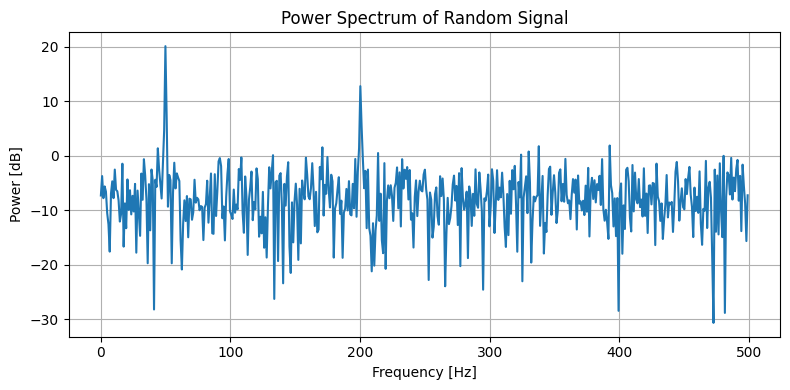

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000            # Sampling frequency (Hz)
N = 1024             # Number of samples
t = np.arange(N) / fs

# Generate a random signal (white noise + two sinusoids)
x = np.random.randn(N) * 0.5 \
    + 0.7*np.sin(2*np.pi*50*t) \
    + 0.3*np.sin(2*np.pi*200*t)

# Compute FFT and power spectrum
X = np.fft.fft(x)
freqs = np.fft.fftfreq(N, 1/fs)
power_spectrum = np.abs(X)**2 / N   # Power per bin

# Keep only positive frequencies
mask = freqs >= 0
freqs = freqs[mask]
power_spectrum = power_spectrum[mask]

# Plot
plt.figure(figsize=(8,4))
plt.plot(freqs, 10*np.log10(power_spectrum), lw=1.5)
plt.title("Power Spectrum of Random Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")
plt.grid(True)
plt.tight_layout()
plt.show()


## Some basic statistical analysis tools (auto/cross-correlation)

Here are a couple of useful code snippets for computing auto/cross-correlations. First for autocorrelation

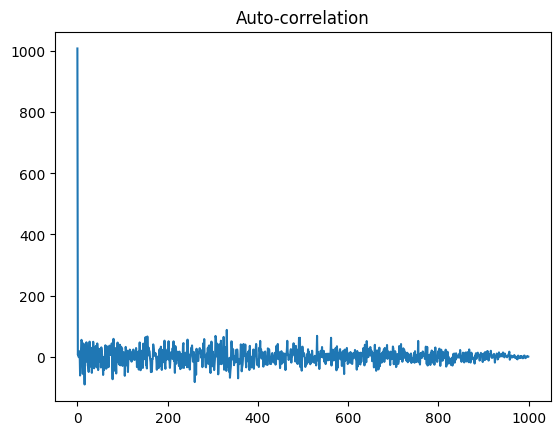

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.randn(1000)
autocorr = np.correlate(x, x, mode='full')
autocorr = autocorr[autocorr.size // 2:]  # keep non-negative lags
plt.plot(autocorr)
plt.title("Auto-correlation")
plt.show()

In [ ]:
Now cross-correlation

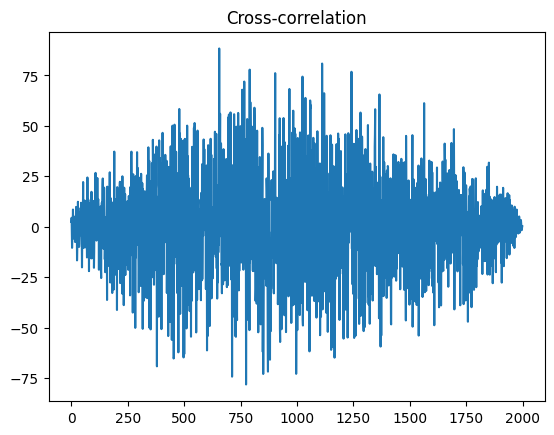

In [4]:
y = np.random.randn(1000)
crosscorr = np.correlate(x, y, mode='full')
plt.plot(crosscorr)
plt.title("Cross-correlation")
plt.show()

You can also use scipy for slightly different versions:

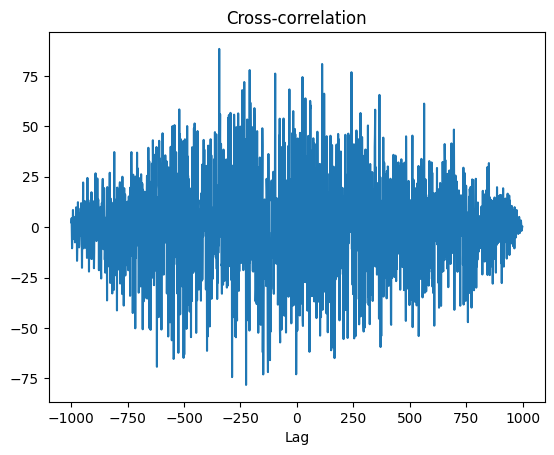

In [5]:
from scipy.signal import correlate, correlation_lags

corr = correlate(x, y, mode='full')
lags = correlation_lags(len(x), len(y), mode='full')
import matplotlib.pyplot as plt
plt.plot(lags, corr)
plt.title("Cross-correlation")
plt.xlabel("Lag")
plt.show()


## Some basic signal processing (convolution)
Here's some sample code for doing convolution, now of complex quantities using both numpy and scipy. They also show more advanced MATLAB-stype plotting using subplots

Max difference: 9.519191346087095e-16


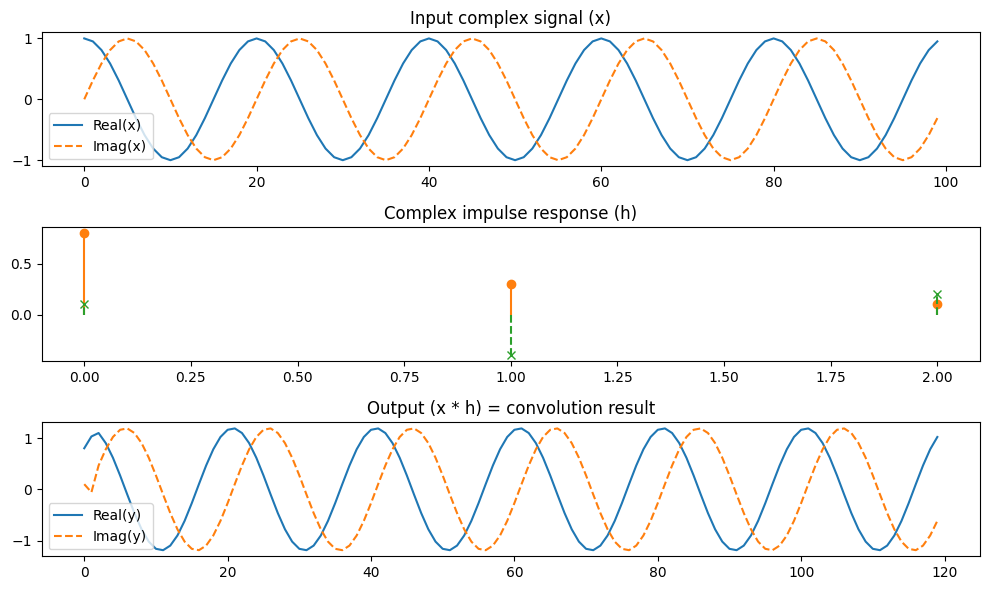

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, fftconvolve

# --- Generate two complex signals ---
fs = 1e3  # sample rate (Hz)
t = np.arange(0, 1, 1/fs)

# Complex exponential (e.g., carrier or tone)
x = np.exp(1j * 2 * np.pi * 50 * t)  # 50 Hz complex tone

# Complex "channel" impulse response (multipath-like)
h = np.array([0.8 + 0.1j, 0.3 - 0.4j, 0.1 + 0.2j])

# --- Perform convolution ---
# 1. Direct convolution with numpy
y_np = np.convolve(x, h, mode='full')

# 2. FFT-based convolution (SciPy)
y_fft = fftconvolve(x, h, mode='full')

# Check they’re (almost) identical numerically
print("Max difference:", np.max(np.abs(y_np - y_fft)))

# --- Plot results ---
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(np.real(x[:100]), label='Real(x)')
plt.plot(np.imag(x[:100]), '--', label='Imag(x)')
plt.title("Input complex signal (x)")
plt.legend()

plt.subplot(3,1,2)
plt.stem(np.real(h), linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.stem(np.imag(h), linefmt='C2--', markerfmt='C2x', basefmt=' ')
plt.title("Complex impulse response (h)")

plt.subplot(3,1,3)
plt.plot(np.real(y_np[:120]), label='Real(y)')
plt.plot(np.imag(y_np[:120]), '--', label='Imag(y)')
plt.title("Output (x * h) = convolution result")
plt.legend()

plt.tight_layout()
plt.show()


## Loading binary format signal files (Octave binary format)
Below is a public-domain script for reading in binary format signal files that are stored for the various lab sessions.


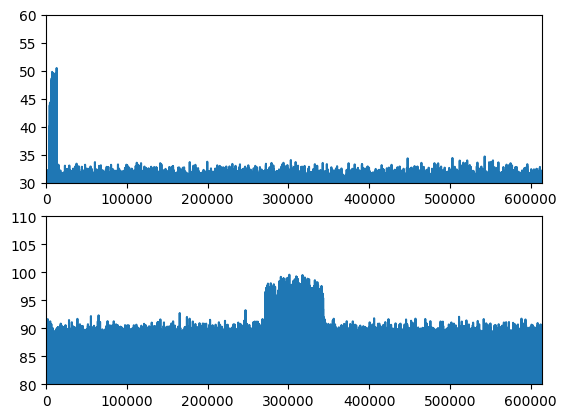

In [27]:
# This code is public domain
from __future__ import print_function

import sys
from collections import OrderedDict

import numpy as np

if sys.version_info[0] > 2:
    def tostr(s):
        return s.decode('utf8')
    def decode(s, encoding='utf8'):
        return s.decode(encoding)
    STR_ENCODING = 'utf8'
else:
    def tostr(s):
        return s
    def decode(s, encoding='utf8'):
        return unicode(s, encoding)
    STR_ENCODING = None

DATA_TYPES = {
    1: "scalar",
    2: "matrix",
    3: "complex scalar",
    4: "complex matrix",
    5: "old_string",
    6: "range",
    7: "string",
}

TYPE_CODES = {
    0: "u1",
    1: "u2",
    2: "u4",
    3: "i1",
    4: "i2",
    5: "i4",
    6: "f4",
    7: "f8",
    8: "u8",
    9: "i8",
}
DTYPES = {k: np.dtype(v) for k, v in TYPE_CODES.items()}

def loadoct(fd, encoding=STR_ENCODING):
    """
    Read an octave binary file from the file handle fd, returning
    an array of structures.  If encoding is not None then convert
    strings from bytes to unicode.  Default is STR_ENCODING, which
    is utf8 for python 3 and None for python 2, yielding arrays
    of type str in each dialect.
    """
    magic = fd.read(10)
    assert(magic == b"Octave-1-L" or magic == b"Octave-1-B")
    endian = "<" if magic[-1:] == b"L" else ">"
    # Float type is 0: IEEE-LE, 1: IEEE-BE, 2: VAX-D, 3: VAX-G, 4: Cray
    # Not used since Octave assumes IEEE format floats.
    _float_format = fd.read(1)
    len_dtype = np.dtype(endian + "i4")
    def read_len():
        len_bytes = fd.read(4)
        if not len_bytes:
            return None
        return np.frombuffer(len_bytes, len_dtype)[0]
    table = OrderedDict()
    while True:
        name_length = read_len()
        if name_length is None:  # EOF
            break
        name = tostr(fd.read(name_length))
        doc_length = read_len()
        doc = tostr(fd.read(doc_length)) if doc_length else ''
        is_global = bool(ord(fd.read(1)))
        data_type = ord(fd.read(1))
        if data_type == 255:
            type_str = tostr(fd.read(read_len()))
        else:
            type_str = DATA_TYPES[data_type]
        #print("reading", name, type_str)
        if type_str.endswith("scalar"):
            if type_str == "scalar":
                dtype = DTYPES[ord(fd.read(1))]
            elif type_str == "complex scalar":
                _ = fd.read(1)
                dtype = np.dtype('complex128')
            elif type_str == "float complex scalar":
                _ = fd.read(1)
                dtype = np.dtype('complex64')
            else:
                dtype = np.dtype(type_str[:-7])
            dtype = dtype.newbyteorder(endian)
            data = np.frombuffer(fd.read(dtype.itemsize), dtype)
            table[name] = data[0]
        elif type_str.endswith("matrix"):
            ndims = read_len()
            if ndims < 0:
                ndims = -ndims
                dims = np.frombuffer(fd.read(4*ndims), len_dtype)
            else:
                dims = (ndims, read_len())
            count = np.prod(dims)
            if type_str == "matrix":
                dtype = DTYPES[ord(fd.read(1))]
            elif type_str == "complex matrix":
                _ = fd.read(1)
                dtype = np.dtype('complex128')
            elif type_str == "float complex matrix":
                _ = fd.read(1)
                dtype = np.dtype('complex64')
            else:
                dtype = np.dtype(type_str[:-7])
            dtype = dtype.newbyteorder(endian)
            data = np.frombuffer(fd.read(count*dtype.itemsize), dtype)
            # Note: Use data.copy() to make a modifiable array.
            table[name] = data.reshape(dims, order='F')
        elif type_str == "old_string":
            data = fd.read(read_len())
            if encoding is not None:
                data = decode(data, encoding)
            table[name] = data
        elif type_str in ("string", "sq_string"):
            nrows = read_len()
            if nrows < 0:
                ndims = -nrows
                dims = np.frombuffer(fd.read(4*ndims), len_dtype)
                count = np.prod(dims)
                fortran_order = np.frombuffer(fd.read(count), dtype='uint8')
                c_order = np.ascontiguousarray(fortran_order.reshape(dims, order='F'))
                data = c_order.view(dtype='|S'+str(dims[-1]))
                if encoding is not None:
                    data = np.array([decode(s, encoding) for s in data.flat])
                table[name] = data.reshape(dims[:-1])
            else:
                data = [fd.read(read_len()) for _ in range(nrows)]
                if encoding is not None:
                    data = [decode(s, encoding) for s in data]
                table[name] = np.array(data)

        else:
            raise NotImplementedError("unknown octave type "+type_str)
        #print("read %s:%s"%(name, type_str), table[name])
    return table

def _dump(filename, encoding=STR_ENCODING):
    import gzip

    if filename.endswith('.gz'):
        with gzip.open(filename, 'rb') as fd:
            table = loadoct(fd, encoding)
    else:
        with open(filename, 'rb') as fd:
            table = loadoct(fd, encoding)
    for k, v in table.items():
        print(k, v)

with open('rxsignal_justnoise.bin','rb') as fd:
    table = loadoct(fd);
    for k,v in table.items():
        rxs0 = v

rxs0 = np.squeeze(rxs0)        
import matplotlib.pyplot as plt
plt.subplot(2,1,1)
plt.plot(20*np.log10(np.abs(rxs0)));
plt.axis([0, 614399, 30, 60]) 
plt.subplot(2,1,2)
plt.plot(20*np.log10(np.abs(np.fft.fftshift(np.fft.fft(rxs0)))))
plt.axis([0, 614399, 80, 110])
plt.show();
